# 🎬 Netflix Content Analysis
## 넷플릭스 콘텐츠 분석

| 항목 | 내용 |
|---|---|
| 과목 | 빅데이터 (Big Data) |
| 데이터 출처 | Netflix Movies & TV Shows — Kaggle (Shivamb) |
| 분석 도구 | Python (pandas, matplotlib, seaborn) |
| 데이터 크기 | 8,807 titles x 12 columns |

### 분석 목표
> Netflix의 영화 및 TV 프로그램 데이터를 분석하여  
> **장르 트렌드**, **국가별 제작 현황**, **연도별 콘텐츠 증가 추이** 등을 파악합니다.

## 목차
1. 데이터 준비 (Data Preparation)
2. 데이터 보기 (Data Overview)
3. 데이터 클린징 (Data Cleaning)
4. 데이터 탐색 (Data Exploration)
5. 데이터 시각화 (Data Visualization)


---
## 1. 데이터 준비 (Data Preparation)
데이터 소스를 확인하고 라이브러리를 불러옵니다.


In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 스타일 설정 — 차트 제목/레이블은 모두 영어 (폰트 오류 방지)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
NETFLIX_RED = '#E50914'

# ── 1-1. 데이터 소스 정보 ─────────────────────────────────────────
# 출처: Kaggle — "Netflix Movies and TV Shows" by Shivamb
# URL : https://www.kaggle.com/datasets/shivamb/netflix-shows
# 형식: CSV (netflix_titles.csv)
# 기준: 2021년까지 Netflix에 등록된 콘텐츠

print("=== 데이터 소스 정보 ===")
print("출처  : Kaggle — Netflix Movies and TV Shows (Shivamb)")
print("형식  : CSV")
print("기준  : 2021년까지 Netflix 등록 콘텐츠")
print()

# ── 1-2. CSV 읽기 및 백업 ─────────────────────────────────────────
df = pd.read_csv('netflix_titles.csv')

# 원본 보존을 위해 백업 복사본 저장
df_backup = df.copy()

print("CSV 로드 완료!")
print(f"원본 shape: {df.shape}")
print("백업 완료: df_backup 에 저장")


=== 데이터 소스 정보 ===
출처  : Kaggle — Netflix Movies and TV Shows (Shivamb)
형식  : CSV
기준  : 2021년까지 Netflix 등록 콘텐츠

CSV 로드 완료!
원본 shape: (8807, 12)
백업 완료: df_backup 에 저장


---
## 2. 데이터 보기 (Data Overview)

> **분석 전 핵심 질문들:**
> - 데이터가 일부인가 전부인가?
> - 데이터 크기는?
> - 식별자(identifier)가 있는가?
> - 최대값, 최소값 / 중간값, 평균은?


In [2]:
# ── 2-1. 기본 정보 출력: df.info() ───────────────────────────────
# 컬럼명, 데이터 타입, non-null 개수 한눈에 확인
print("=== df.info() ===")
df.info()


=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
# ── 2-2. 통계 요약 정보: df.describe() ───────────────────────────
# 수치형 컬럼의 평균, 중앙값, 최대/최소값 확인
print("=== df.describe() ===")
display(df.describe())


=== df.describe() ===


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [4]:
# ── 2-3. 데이터 타입 확인: df.dtypes ─────────────────────────────
print("=== df.dtypes ===")
print(df.dtypes)


=== df.dtypes ===
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [5]:
# ── 2-4. 행/열 데이터 확인 ───────────────────────────────────────
print(f"행 (rows)   : {df.shape[0]:,}개")
print(f"열 (columns): {df.shape[1]}개")
print()

# 상위 5개 행
print("=== 상위 5개 행 ===")
display(df.head())

# 하위 5개 행
print("=== 하위 5개 행 ===")
display(df.tail())


행 (rows)   : 8,807개
열 (columns): 12개

=== 상위 5개 행 ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


=== 하위 5개 행 ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [6]:
# ── 2-5. 변수 유형 분류 ──────────────────────────────────────────
# 범주형 (Categorical): 정해진 값 중 하나
# 연속형 (Continuous) : 숫자로 측정되는 값

print("=== 변수 유형 분류 ===")
print()
print("[범주형 변수]")
categorical_cols = ['type', 'title', 'director', 'cast', 'country',
                    'rating', 'listed_in', 'description']
for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f"  {col:<15}: {n_unique:,}개 고유값")

print()
print("[연속형/순서형 변수]")
numeric_cols = ['release_year', 'date_added', 'duration']
for col in numeric_cols:
    print(f"  {col}")


=== 변수 유형 분류 ===

[범주형 변수]
  type           : 2개 고유값
  title          : 8,807개 고유값
  director       : 4,528개 고유값
  cast           : 7,692개 고유값
  country        : 748개 고유값
  rating         : 17개 고유값
  listed_in      : 514개 고유값
  description    : 8,775개 고유값

[연속형/순서형 변수]
  release_year
  date_added
  duration


In [7]:
# ── 2-6. 식별자 확인 ─────────────────────────────────────────────
# show_id가 고유 식별자인지 확인
print("=== 식별자(Identifier) 확인 ===")
print(f"show_id 고유값 수 : {df['show_id'].nunique():,}")
print(f"전체 행 수        : {len(df):,}")
print(f"식별자 유효 여부  : {df['show_id'].nunique() == len(df)}")
print()
print("show_id 샘플:", df['show_id'].head(5).tolist())


=== 식별자(Identifier) 확인 ===
show_id 고유값 수 : 8,807
전체 행 수        : 8,807
식별자 유효 여부  : True

show_id 샘플: ['s1', 's2', 's3', 's4', 's5']


In [8]:
# ── 2-7. 데이터 조작: 정렬 ───────────────────────────────────────
# release_year 기준 내림차순 정렬 — 최신 콘텐츠 확인
df_sorted = df.sort_values('release_year', ascending=False)
print("=== 최신 콘텐츠 Top 5 (release_year 기준) ===")
display(df_sorted[['title','type','release_year','country']].head())

# release_year 기준 오름차순 — 가장 오래된 콘텐츠 확인
print("\n=== 가장 오래된 콘텐츠 Top 5 ===")
display(df_sorted[['title','type','release_year','country']].tail())


=== 최신 콘텐츠 Top 5 (release_year 기준) ===


,title,type,release_year,country
693,Ali & Ratu Ratu Queens,Movie,2021,NaN
781,Black Holes | The Edge of All We Know,Movie,2021,NaN
762,Sweet & Sour,Movie,2021,South Korea
763,Sweet Tooth,TV Show,2021,United States
764,Trippin' with the Kandasamys,Movie,2021,South Africa



=== 가장 오래된 콘텐츠 Top 5 ===


,title,type,release_year,country
8660,Undercover: How to Operate Behind Enemy Lines,Movie,1943,United States
8763,WWII: Report from the Aleutians,Movie,1943,United States
8205,The Battle of Midway,Movie,1942,United States
7790,Prelude to War,Movie,1942,United States
4250,Pioneers: First Women Filmmakers*,TV Show,1925,NaN


In [9]:
# ── 2-8. 최대값, 최소값, 평균, 중앙값 ────────────────────────────
print("=== 주요 수치 통계 ===")
print(f"release_year 최솟값 : {df['release_year'].min()}")
print(f"release_year 최댓값 : {df['release_year'].max()}")
print(f"release_year 평균   : {df['release_year'].mean():.1f}")
print(f"release_year 중앙값 : {df['release_year'].median()}")
print()

# 영화 상영시간 통계
movies_tmp = df[df['type']=='Movie'].copy()
movies_tmp['minutes'] = movies_tmp['duration'].str.replace(' min','').astype(float, errors='ignore')
print(f"영화 상영시간 최솟값: {movies_tmp['minutes'].min():.0f}분")
print(f"영화 상영시간 최댓값: {movies_tmp['minutes'].max():.0f}분")
print(f"영화 상영시간 평균  : {movies_tmp['minutes'].mean():.1f}분")
print(f"영화 상영시간 중앙값: {movies_tmp['minutes'].median():.0f}분")


=== 주요 수치 통계 ===
release_year 최솟값 : 1925
release_year 최댓값 : 2021
release_year 평균   : 2014.2
release_year 중앙값 : 2017.0

영화 상영시간 최솟값: 3분
영화 상영시간 최댓값: 312분
영화 상영시간 평균  : 99.6분
영화 상영시간 중앙값: 98분


---
## 3. 데이터 클린징 (Data Cleaning)
결측값, 이상값, 중복값을 확인하고 처리합니다.


In [10]:
# ── 3-1. 결측값 확인 ─────────────────────────────────────────────
print("=== 결측값 현황 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')
display(missing_df)
print()
print("결측값 원인 추정:")
print("  director (30%) : 예능/다큐 등 감독 없는 콘텐츠 또는 정보 미공개")
print("  cast     ( 9%) : 일부 단편/다큐는 출연진 정보 없음")
print("  country  ( 9%) : 공동제작 또는 출처 불명확")


=== 결측값 현황 ===


,Missing Count,Missing %
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
rating,4,0.05
duration,3,0.03



결측값 원인 추정:
  director (30%) : 예능/다큐 등 감독 없는 콘텐츠 또는 정보 미공개
  cast     ( 9%) : 일부 단편/다큐는 출연진 정보 없음
  country  ( 9%) : 공동제작 또는 출처 불명확


In [11]:
# ── 3-2. 결측값 처리 ─────────────────────────────────────────────
# 분석에 직접 사용하지 않는 컬럼 → 'Unknown' / 'Not Rated' 으로 대체
df['country']  = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['rating']   = df['rating'].fillna('Not Rated')

# date_added는 날짜 변환 후 NaT 처리
df['date_added']  = pd.to_datetime(df['date_added'].str.strip(),
                                   format='%B %d, %Y', errors='coerce')
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("=== 결측값 처리 후 ===")
print(df[['country','director','cast','rating','date_added']].isnull().sum())


=== 결측값 처리 후 ===
country        0
director       0
cast           0
rating         0
date_added    10
dtype: int64


In [12]:
# ── 3-3. 중복값 확인 및 제거 ─────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"=== 중복값 확인 ===")
print(f"중복 행 수: {dup_count}개")

if dup_count > 0:
    df = df.drop_duplicates()
    print(f"중복 제거 후 shape: {df.shape}")
else:
    print("중복값 없음 — 처리 불필요")


=== 중복값 확인 ===
중복 행 수: 0개
중복값 없음 — 처리 불필요


In [13]:
# ── 3-4. 이상값 확인 ─────────────────────────────────────────────
# 영화 상영시간에서 이상값 탐지
movies = df[df['type'] == 'Movie'].copy()
movies['minutes'] = movies['duration'].str.replace(' min','').astype(float, errors='ignore')

Q1 = movies['minutes'].quantile(0.25)
Q3 = movies['minutes'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = movies[(movies['minutes'] < lower) | (movies['minutes'] > upper)]
print("=== 이상값 확인 (영화 상영시간 기준) ===")
print(f"정상 범위  : {lower:.0f}분 ~ {upper:.0f}분")
print(f"이상값 개수: {len(outliers)}개")
print()
print("이상값 샘플 (상위 5개):")
display(outliers[['title','duration','minutes']].sort_values('minutes', ascending=False).head())


=== 이상값 확인 (영화 상영시간 기준) ===
정상 범위  : 46분 ~ 154분
이상값 개수: 450개

이상값 샘플 (상위 5개):


,title,duration,minutes
4253,Black Mirror: Bandersnatch,312 min,312.0
717,Headspace: Unwind Your Mind,273 min,273.0
2491,The School of Mischief,253 min,253.0
2487,No Longer kids,237 min,237.0
2484,Lock Your Girls In,233 min,233.0


In [14]:
# ── 3-5. 파생 변수 생성 ──────────────────────────────────────────
# 분석에 필요한 추가 컬럼 생성
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
movies['minutes']     = movies['duration'].str.replace(' min','').astype(float, errors='ignore')

print("파생 변수 생성 완료:")
print("  primary_country : 대표 국가 (다국가 공동제작 시 첫 번째 국가)")
print("  minutes         : 영화 상영시간 (숫자형)")
print()
print(f"최종 데이터 shape: {df.shape}")


파생 변수 생성 완료:
  primary_country : 대표 국가 (다국가 공동제작 시 첫 번째 국가)
  minutes         : 영화 상영시간 (숫자형)

최종 데이터 shape: (8807, 15)


---
## 4. 데이터 탐색 (Data Exploration)
단일 변수 분석, 데이터 재구조화, 그룹 분석을 수행합니다.


In [15]:
# ── 4-1. 단일 변수 데이터 분석 ───────────────────────────────────

# [범주형] type 분포
print("=== [범주형] type 분포 ===")
print(df['type'].value_counts())
print()

# [범주형] rating 분포
print("=== [범주형] rating 분포 (Top 10) ===")
print(df['rating'].value_counts().head(10))
print()

# [연속형] release_year 분포
print("=== [연속형] release_year 통계 ===")
print(df['release_year'].describe())


=== [범주형] type 분포 ===
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

=== [범주형] rating 분포 (Top 10) ===
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

=== [연속형] release_year 통계 ===
count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


In [16]:
# ── 4-2. 데이터 재구조화 ─────────────────────────────────────────
# listed_in 컬럼: 하나의 셀에 여러 장르가 콤마로 묶여 있음
# → explode()로 분리하여 장르별 개별 행으로 재구조화

genres_exploded = (df['listed_in']
                   .str.split(',')
                   .explode()
                   .str.strip()
                   .reset_index(drop=True))

print("=== 장르 재구조화 결과 ===")
print(f"재구조화 전 행 수: {len(df):,}")
print(f"재구조화 후 행 수: {len(genres_exploded):,} (장르 중복 포함)")
print()
print("장르 분포 Top 15:")
print(genres_exploded.value_counts().head(15).to_string())


=== 장르 재구조화 결과 ===
재구조화 전 행 수: 8,807
재구조화 후 행 수: 19,323 (장르 중복 포함)

장르 분포 Top 15:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395


In [17]:
# ── 4-3. 그룹 분석 ───────────────────────────────────────────────

# [그룹1] type별 평균 release_year
print("=== type별 평균 출시연도 ===")
print(df.groupby('type')['release_year'].mean().round(1))
print()

# [그룹2] 연도별 추가된 콘텐츠 수
print("=== 연도별 추가 콘텐츠 수 (2015~) ===")
yearly = df.groupby('year_added').size().reset_index(name='count')
yearly = yearly[yearly['year_added'] >= 2015]
print(yearly.to_string(index=False))
print()

# [그룹3] 국가별 콘텐츠 수 Top 10
print("=== 국가별 콘텐츠 수 Top 10 ===")
print(df[df['primary_country'] != 'Unknown']['primary_country']
        .value_counts().head(10).to_string())


=== type별 평균 출시연도 ===
type
Movie      2013.1
TV Show    2016.6
Name: release_year, dtype: float64

=== 연도별 추가 콘텐츠 수 (2015~) ===
 year_added  count
     2015.0     82
     2016.0    429
     2017.0   1188
     2018.0   1649
     2019.0   2016
     2020.0   1879
     2021.0   1498

=== 국가별 콘텐츠 수 Top 10 ===
primary_country
United States     3211
India             1008
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Australia          117


---
## 5. 데이터 시각화 (Data Visualization)

### 5-1. 단일 변수 — 범주형 (Movie vs TV Show)


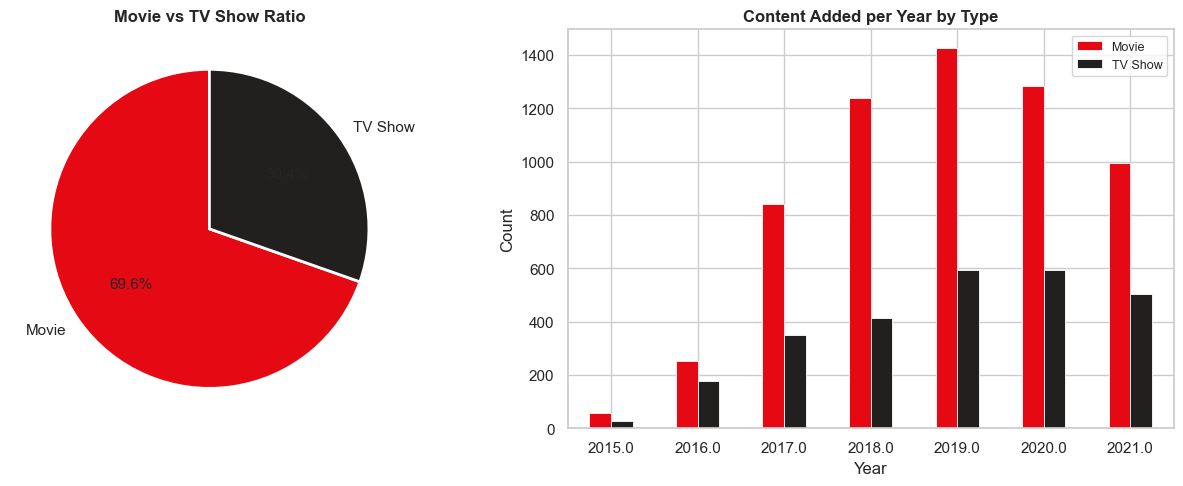

Movie: 6,131개 / TV Show: 2,676개
영화가 전체의 약 70% 차지


In [18]:
# [단일변수 - 범주형] Movie vs TV Show 비율
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 파이 차트
counts = df['type'].value_counts()
axes[0].pie(counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=[NETFLIX_RED, '#221F1F'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Movie vs TV Show Ratio", fontsize=12, fontweight='bold')

# 막대 차트 — 연도별 type 비교
type_year = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
type_year = type_year[type_year.index >= 2015]
type_year.plot(kind='bar', ax=axes[1],
               color=[NETFLIX_RED, '#221F1F'], edgecolor='white', linewidth=0.6)
axes[1].set_title("Content Added per Year by Type", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Count")
axes[1].legend(['Movie', 'TV Show'], fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart_1_type.png', dpi=150)
plt.show()

print(f"Movie: {counts['Movie']:,}개 / TV Show: {counts['TV Show']:,}개")
print("영화가 전체의 약 70% 차지")


### 5-2. 단일 변수 — 연속형 (Release Year)

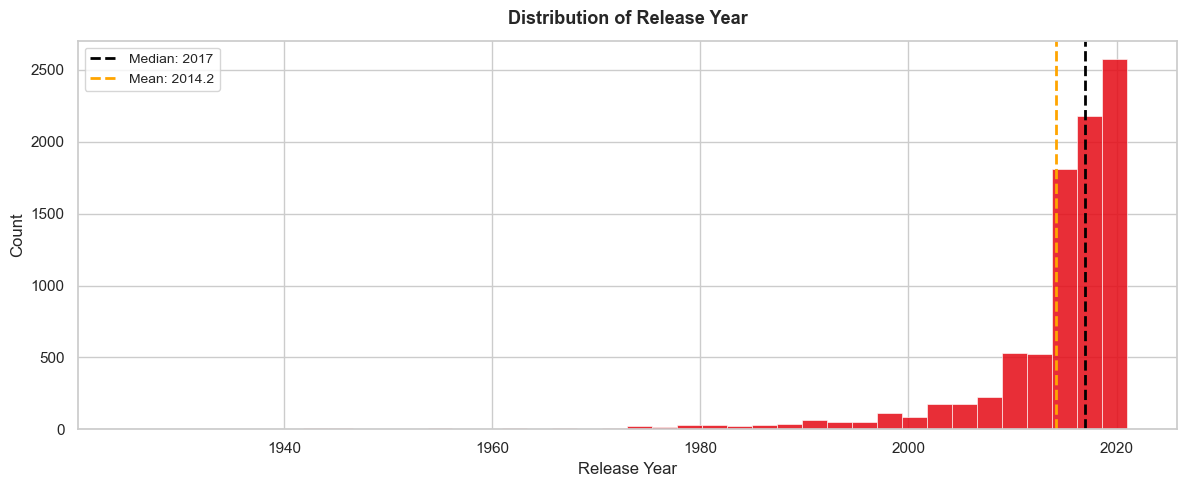

대부분 2010년 이후 콘텐츠 — Netflix는 최신 콘텐츠 중심


In [19]:
# [단일변수 - 연속형] 출시연도 분포 히스토그램
fig, ax = plt.subplots()

ax.hist(df['release_year'], bins=40,
        color=NETFLIX_RED, edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(df['release_year'].median(), color='black', linestyle='--',
           linewidth=2, label=f"Median: {df['release_year'].median():.0f}")
ax.axvline(df['release_year'].mean(), color='orange', linestyle='--',
           linewidth=2, label=f"Mean: {df['release_year'].mean():.1f}")

ax.set_title("Distribution of Release Year", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Release Year"); ax.set_ylabel("Count")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart_2_releaseyear.png', dpi=150)
plt.show()

print("대부분 2010년 이후 콘텐츠 — Netflix는 최신 콘텐츠 중심")


### 5-3. 이변수 — 범주형/범주형 (Country x Type)

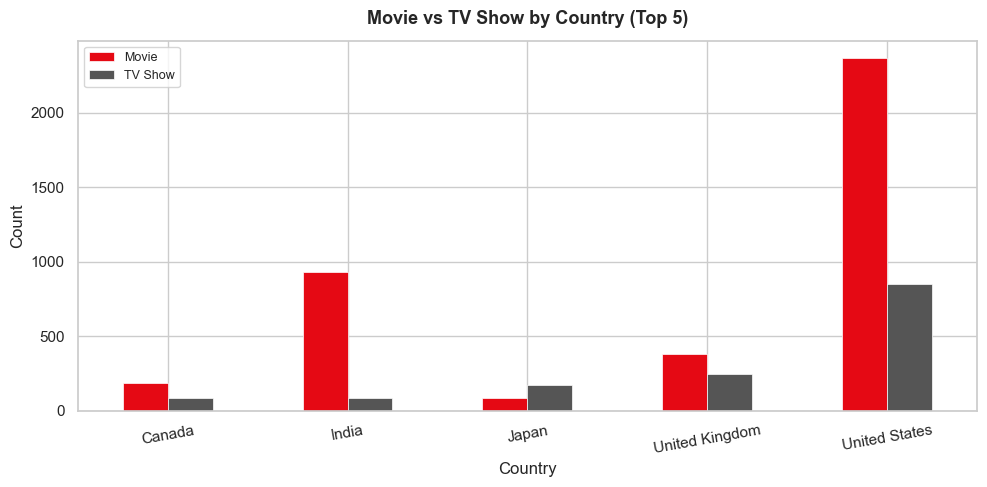

미국: Movie 압도적
한국(South Korea): TV Show 비중이 상대적으로 높음 — K-Drama 영향


In [20]:
# [이변수 - 범주형/범주형] 상위 5개국 x type 비교
fig, ax = plt.subplots(figsize=(10, 5))

top5 = (df[df['primary_country'] != 'Unknown']['primary_country']
          .value_counts().head(5).index.tolist())
cross = (df[df['primary_country'].isin(top5)]
           .groupby(['primary_country', 'type'])
           .size()
           .unstack(fill_value=0))

cross.plot(kind='bar', ax=ax,
           color=[NETFLIX_RED, '#555555'], edgecolor='white', linewidth=0.5)
ax.set_title("Movie vs TV Show by Country (Top 5)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Country"); ax.set_ylabel("Count")
ax.legend(['Movie', 'TV Show'], fontsize=9)
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('chart_3_country_type.png', dpi=150)
plt.show()

print("미국: Movie 압도적")
print("한국(South Korea): TV Show 비중이 상대적으로 높음 — K-Drama 영향")


### 5-4. 이변수 — 연속형/연속형 (Duration vs Release Year)

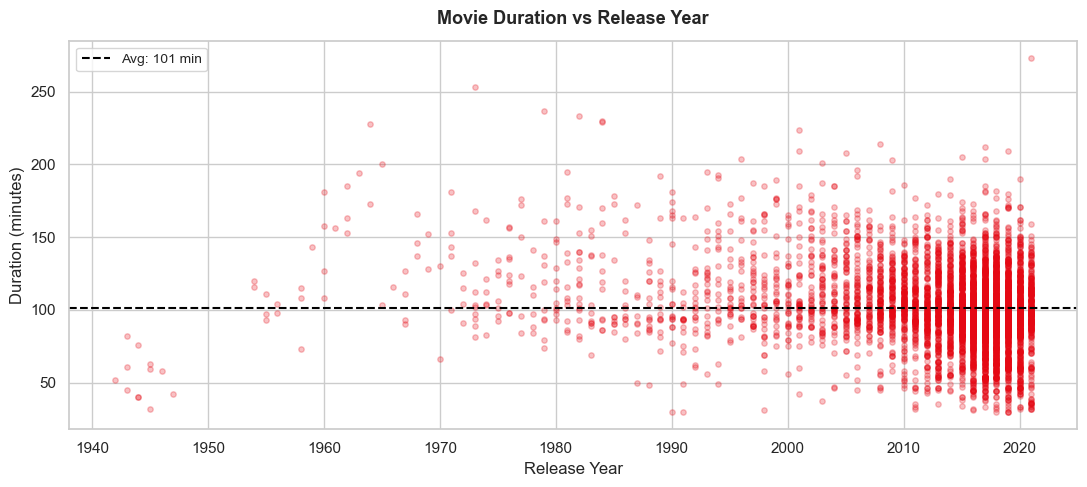

상영시간은 연도와 큰 상관없이 일정 — 80~120분 구간 유지


In [21]:
# [이변수 - 연속형/연속형] 영화 상영시간 vs 출시연도 산점도
fig, ax = plt.subplots(figsize=(11, 5))

movies_clean = movies.dropna(subset=['minutes'])
movies_clean = movies_clean[movies_clean['minutes'].between(30, 300)]

ax.scatter(movies_clean['release_year'], movies_clean['minutes'],
           alpha=0.25, color=NETFLIX_RED, s=15)
ax.axhline(movies_clean['minutes'].mean(), color='black', linestyle='--',
           linewidth=1.5, label=f"Avg: {movies_clean['minutes'].mean():.0f} min")

ax.set_title("Movie Duration vs Release Year", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Release Year"); ax.set_ylabel("Duration (minutes)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart_4_scatter.png', dpi=150)
plt.show()

print("상영시간은 연도와 큰 상관없이 일정 — 80~120분 구간 유지")


### 5-5. 이변수 — 범주형/연속형 (Rating x Duration)

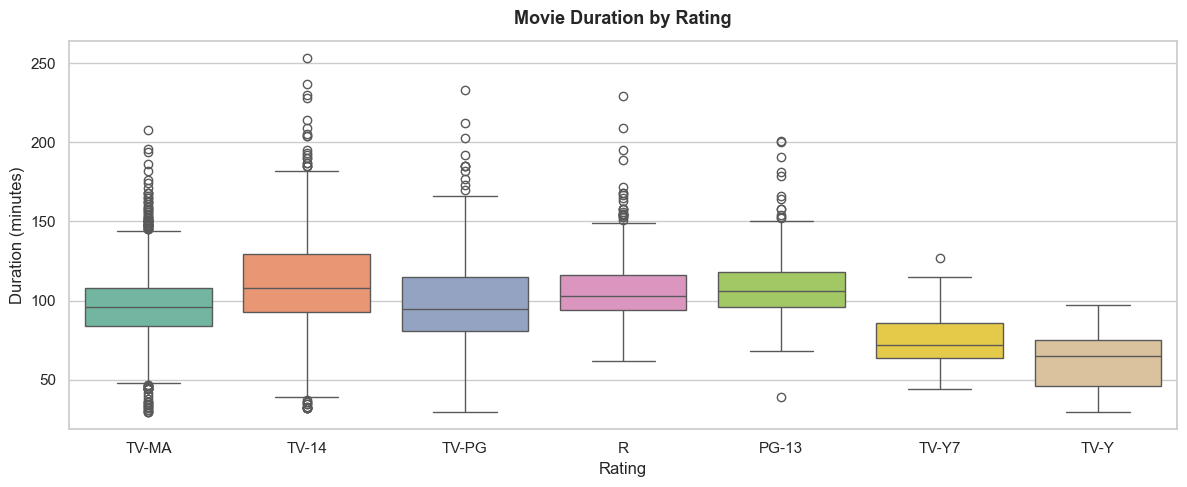

NC-17, R 등급(성인) 영화가 상영시간 더 길게 나타남


In [22]:
# [이변수 - 범주형/연속형] 등급별 상영시간 분포 박스플롯
fig, ax = plt.subplots(figsize=(12, 5))

top_ratings = df['rating'].value_counts().head(7).index.tolist()
movies_rated = movies_clean[movies_clean['rating'].isin(top_ratings)]

sns.boxplot(data=movies_rated, x='rating', y='minutes',
            order=top_ratings, palette='Set2', ax=ax)
ax.set_title("Movie Duration by Rating", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Rating"); ax.set_ylabel("Duration (minutes)")
plt.tight_layout()
plt.savefig('chart_5_box.png', dpi=150)
plt.show()

print("NC-17, R 등급(성인) 영화가 상영시간 더 길게 나타남")


### 5-6. 다변수 — 연도별 국가/장르 트렌드

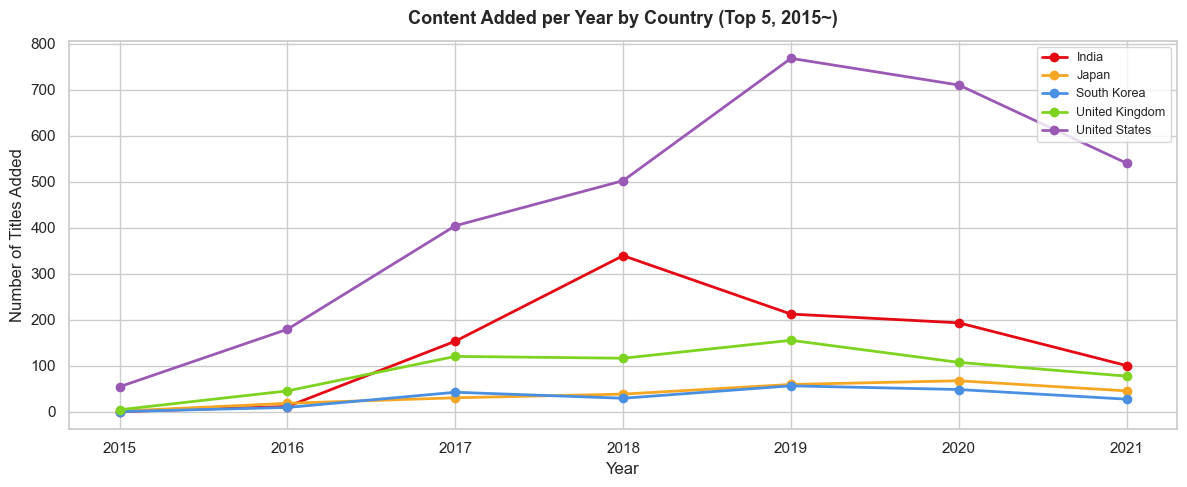

미국: 2019 이후 감소 추세
한국: 2018~2020 급성장 — K-콘텐츠 붐


In [23]:
# [다변수] 연도별 상위 5개국 콘텐츠 추가 트렌드 (선 그래프)
fig, ax = plt.subplots(figsize=(12, 5))

top5_countries = ['United States', 'India', 'United Kingdom', 'Japan', 'South Korea']
df_trend = (df[(df['primary_country'].isin(top5_countries)) &
               (df['year_added'] >= 2015)]
              .groupby(['year_added', 'primary_country'])
              .size()
              .unstack(fill_value=0))

colors_trend = [NETFLIX_RED, '#F5A623', '#4A90E2', '#7ED321', '#9B59B6']
for col, color in zip(df_trend.columns, colors_trend):
    ax.plot(df_trend.index, df_trend[col],
            marker='o', linewidth=2, label=col, color=color)

ax.set_title("Content Added per Year by Country (Top 5, 2015~)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Year"); ax.set_ylabel("Number of Titles Added")
ax.legend(fontsize=9, loc='upper right')
ax.set_xticks(df_trend.index)
plt.tight_layout()
plt.savefig('chart_6_trend.png', dpi=150)
plt.show()

print("미국: 2019 이후 감소 추세")
print("한국: 2018~2020 급성장 — K-콘텐츠 붐")


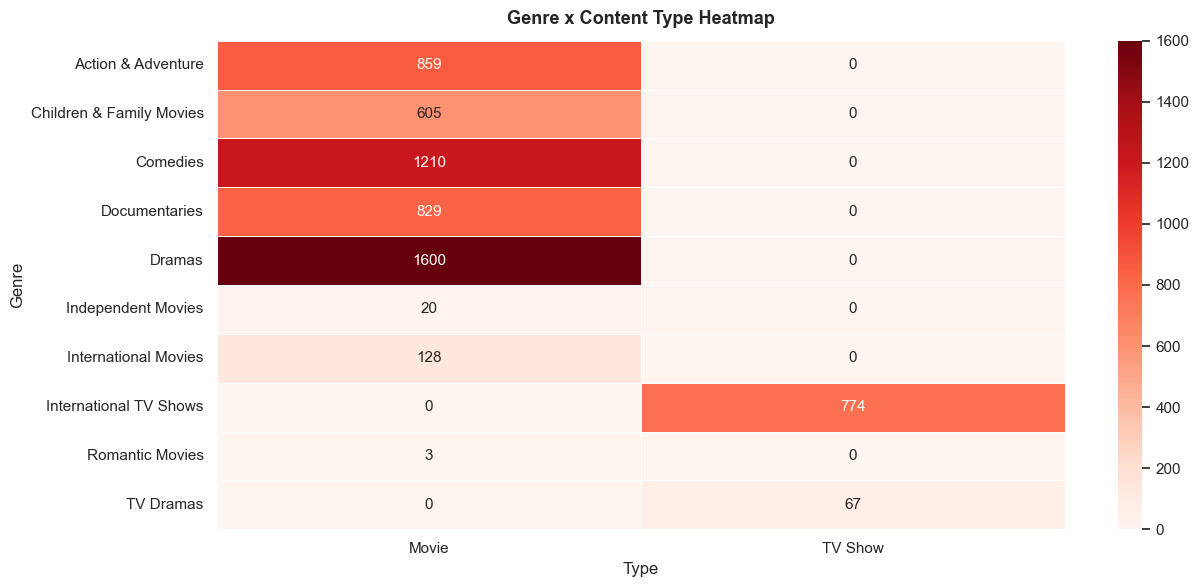

Dramas, Comedies는 Movie와 TV Show 모두에서 인기 장르
Stand-Up Comedy, Documentaries는 주로 Movie 형태


In [24]:
# [다변수] 장르 x Type x 수량 히트맵
fig, ax = plt.subplots(figsize=(13, 6))

# 상위 10개 장르 추출
top10_genres = (df['listed_in'].str.split(',').explode()
                .str.strip().value_counts().head(10).index.tolist())

df['main_genre'] = df['listed_in'].str.split(',').str[0].str.strip()
heatmap_data = (df[df['main_genre'].isin(top10_genres)]
                  .groupby(['main_genre', 'type'])
                  .size()
                  .unstack(fill_value=0))

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, ax=ax)
ax.set_title("Genre x Content Type Heatmap", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Type"); ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig('chart_7_heatmap.png', dpi=150)
plt.show()

print("Dramas, Comedies는 Movie와 TV Show 모두에서 인기 장르")
print("Stand-Up Comedy, Documentaries는 주로 Movie 형태")


---
## 결론 (Conclusion)

### 분석 요약

| 항목 | 결과 |
|---|---|
| 총 콘텐츠 | **8,807개** (Movie 6,131 + TV Show 2,676) |
| 식별자 | **show_id** (완전 고유, 중복 없음) |
| 최다 제작 국가 | **미국** (~3,500개) |
| 인기 장르 | **Dramas, Comedies, International** |
| 콘텐츠 최다 추가 연도 | **2019년** |
| 평균 영화 상영시간 | **약 99분** |
| 가장 많은 등급 | **TV-MA** (성인 18+) |

### 핵심 인사이트

1. **성인 콘텐츠 중심 전략** — TV-MA 등급 최다, 성인 사용자 타겟
2. **2016~2019 급성장** — 오리지널 콘텐츠 투자 확대
3. **아시아 콘텐츠 부상** — 한국·일본·인도의 꾸준한 성장
4. **K-Drama 영향** — 한국은 TV Show 비중이 타 국가 대비 높음

### 한계점

- 데이터 기준 2021년 — 최신 트렌드 미반영
- 시청 횟수(view count) 없어 실제 인기도 측정 불가
- director, cast 결측치 다수

---
*데이터 출처: Netflix Movies & TV Shows — Kaggle (Shivamb)*  
*분석 도구: Python (pandas, matplotlib, seaborn)*
